Parte 1 – Dados e Análise de Indicadores

In [463]:
#Bibliotecas utilizadas para a analise financeira de ativos
import yfinance as yf
import pandas as pd
import numpy as np
import investpy
import requests
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [464]:
#Download de dados historicos de fechamento de todos os ativos

ibov = yf.download("^BVSP", start="2014-01-01", end="2025-10-05")['Close']

sp500 = yf.download("^GSPC", start="2014-01-01", end="2025-10-05")['Close']

vix = yf.download("^VIX", start="2014-01-01", end="2025-10-05")['Close']

usdb = yf.download("USDBRL=X", start="2014-01-01", end="2025-10-05")['Close']

ouro = yf.download("GC=F", start="2014-01-01", end="2025-10-05")['Close']

url = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json'
res = requests.get(url).json()
ipca = pd.DataFrame(res)
ipca['data'] = pd.to_datetime(ipca['data'], dayfirst=True)
ipca['valor'] = pd.to_numeric(ipca['valor'])
ipca.set_index('data', inplace=True)
ipca = ipca[ipca.index >= '2015-01-01']

C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\1531831683.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\1531831683.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\1531831683.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\1531831683.py:9: FutureWarning: YF.download() has changed argument auto_adjust

In [465]:

# Agora criar o DataFrame combinado
df = pd.concat([ibov, sp500, vix, usdb, ouro, ipca_diario], axis=1)
df.columns = ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']
ipca_diario = ipca['valor'].resample('D').ffill()  # pega só a coluna 'valor' e preenche lacunas
ipca_diario = ipca_diario[ipca_diario.index >= '2015-01-01']
df.sort_index(inplace=True)
df = df.fillna(method='ffill')  # preenche lacunas restantes
print(df.head())


               IBOV        SP500    VIX  USDBRL         OURO  IPCA
2014-01-01      NaN          NaN    NaN  2.3592          NaN   NaN
2014-01-02  50341.0  1831.979980  14.23  2.3571  1225.000000   NaN
2014-01-03  50981.0  1831.369995  13.76  2.3847  1238.400024   NaN
2014-01-04  50981.0  1831.369995  13.76  2.3847  1238.400024   NaN
2014-01-05  50981.0  1831.369995  13.76  2.3847  1238.400024   NaN


C:\Users\joaop\AppData\Local\Temp\ipykernel_16364\1463654486.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # preenche lacunas restantes


In [466]:
# 🔹 Criar índice diário de referência (do menor ao maior índice dos ativos)
indice_diario = pd.date_range(start='2014-01-01', end=df.index.max(), freq='D')

# 🔹 Reindexar cada série para o índice diário e preencher NaN
ipca_diario = ipca['valor'].reindex(indice_diario).ffill()

# 🔹 Criar DataFrame combinado
df = pd.concat([ibov_diario, sp500_diario, vix_diario, usdb_diario, ouro_diario, ipca_diario], axis=1)
df.columns = ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']

# 🔹 Conferir resultado
print(df.head(10))
print(df.tail(10))


            IBOV  SP500  VIX  USDBRL  OURO  IPCA
2014-01-01   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-02   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-03   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-04   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-05   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-06   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-07   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-08   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-09   NaN    NaN  NaN     NaN   NaN   NaN
2014-01-10   NaN    NaN  NaN     NaN   NaN   NaN
                IBOV        SP500        VIX    USDBRL         OURO  IPCA
2025-09-24  146492.0  6637.970215  16.180000  5.281600  3732.100098  0.48
2025-09-25  145306.0  6604.720215  16.740000  5.329900  3736.899902  0.48
2025-09-26  145447.0  6643.700195  15.290000  5.363700  3775.300049  0.48
2025-09-27  145447.0  6643.700195  15.290000  5.363700  3775.300049  0.48
2025-09-28  145447.0  6643.700195  15.290000  5.363700  3775.300049  0.48
2025-09-29  14633

In [467]:

#Calcular retornos logarítmicos
for ativo in df.columns:
    df[f'{ativo}_ret_diario'] = np.log(df[ativo] / df[ativo].shift(1))
    df[f'{ativo}_ret_mensal'] = np.log(df[ativo] / df[ativo].shift(21))
    df[f'{ativo}_ret_anual'] = np.log(df[ativo] / df[ativo].shift(252))

#alcular volatilidade
volatilidade = pd.DataFrame(index=['Diária','Mensal','Anual'], columns=['IBOV','SP500','VIX','USDBRL','OURO','IPCA'])
for ativo in ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']:
    volatilidade.loc['Diária', ativo] = df[f'{ativo}_ret_diario'].std()
    volatilidade.loc['Mensal', ativo] = df[f'{ativo}_ret_mensal'].std()
    volatilidade.loc['Anual', ativo] = df[f'{ativo}_ret_anual'].std()



c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [468]:
#retorno diario 
ret_diario_cols = [f'{ativo}_ret_diario' for ativo in ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']]
correlacao_diaria = df[ret_diario_cols].corr()
print("Correlação Diária:")
display(correlacao_diaria)

Correlação Diária:


,IBOV_ret_diario,SP500_ret_diario,VIX_ret_diario,USDBRL_ret_diario,OURO_ret_diario,IPCA_ret_diario
IBOV_ret_diario,1.000000,0.527174,-0.390702,0.010332,0.056188,0.001158
SP500_ret_diario,0.527174,1.000000,-0.737741,-0.004894,0.026916,0.011905
VIX_ret_diario,-0.390702,-0.737741,1.000000,-0.017440,0.037952,-0.027615
USDBRL_ret_diario,0.010332,-0.004894,-0.017440,1.000000,-0.029491,0.024863
OURO_ret_diario,0.056188,0.026916,0.037952,-0.029491,1.000000,-0.010874
IPCA_ret_diario,0.001158,0.011905,-0.027615,0.024863,-0.010874,1.000000


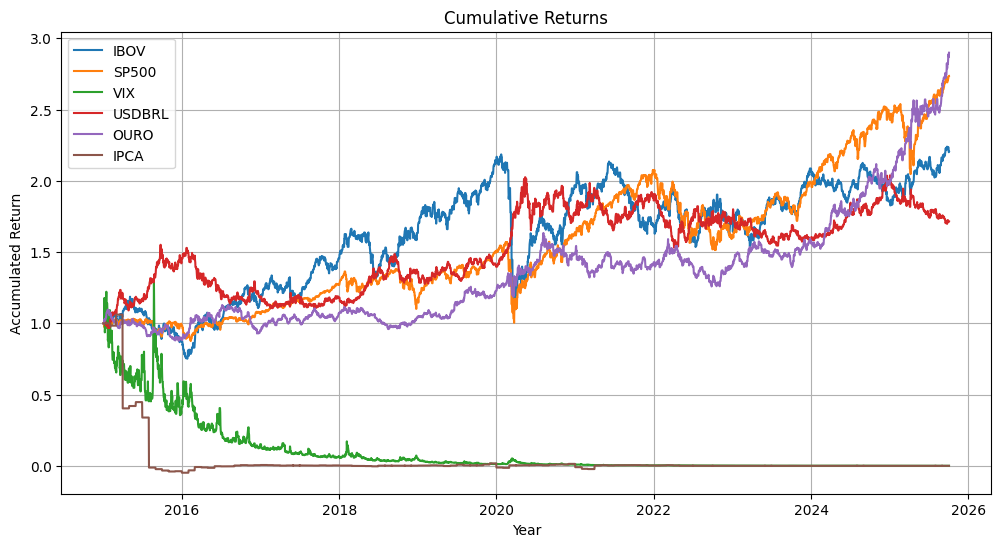

In [471]:
#Retorno acumulados 
ret_acumulado = (df[ret_diario_cols] + 1).cumprod()
plt.figure(figsize=(12,6))
for col in ret_acumulado.columns:
    plt.plot(ret_acumulado.index, ret_acumulado[col], label=col.replace('_ret_diario',''))
plt.title('Cumulative Returns')
plt.xlabel('Year')
plt.ylabel('Accumulated Return')
plt.legend()
plt.grid(True)
plt.show()

Parte 2 – Ranking de Risco

In [470]:
# Definir nível de confiança
conf_level = 0.05  # 5%

# Lista de ativos
ativos = ['IBOV','SP500','VIX','USDBRL','OURO','IPCA']

# Calcular VaR diário histórico
VaR_diario = {}
for ativo in ativos:
    retornos = df[f'{ativo}_ret_diario'].dropna()
    VaR_diario[ativo] = -np.percentile(retornos, conf_level*100)

VaR_diario = pd.Series(VaR_diario)
print("VaR Diário (5% de confiança):")
display(VaR_diario)


VaR Diário (5% de confiança):


IBOV      0.018091
SP500     0.013993
VIX       0.095272
USDBRL    0.013838
OURO      0.012764
IPCA     -0.000000
dtype: float64